In [28]:
#Weighted histograms: coffea env
#Manage the bins
#Add more signal samples

In [29]:

%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import json
import boost_histogram as bh
import uproot
from scipy.stats import beta
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
with open('../configs/sample_configs/signal_2022_Mchi_10_30_50_aEM.json') as file:
    sig_file = json.load(file)

In [31]:
loc = sig_file[2]["location"]
sig_root = uproot.open(loc)
sig_root.keys()
ntuple = sig_root["ntuples/outT"]
# ntuple.keys()
# print (ntuple["genWgt"].array())
# print (sum(ntuple["genWgt"].array()))

In [32]:
met_trig = ntuple["trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight"].array()
print (met_trig)
len (met_trig)

[True, True, False, False, True, False, ... False, True, True, False, True, False]


69068

In [33]:
#Kinematic cut applied:

PFMET_pt=ntuple["PFMET_pt"].array()

CaloMET_pt=ntuple["CaloMET_pt"].array()
diff = abs(PFMET_pt-CaloMET_pt)

r = diff/(CaloMET_pt)
cut = (r <0.5)

print (cut)
len (cut)

[True, True, True, True, False, True, True, ... True, True, True, True, True, True]


69068

In [34]:
bins = np.linspace(0, 600, 60)  
den = PFMET_pt[cut]
num = PFMET_pt[(cut) & (met_trig)]

[   0    0    0    0    0    0    9   19   49  126  262  575 1054 1532
 1900 2127 2030 1855 1603 1388 1243  991  775  673  555  484  414  346
  267  230  208  143  172  136  140  112   86   83   64   50   54   49
   42   27   31   30   32   16   19   12   14    9   11   10    9    7
    6    6    6]
[   0   13   81  236  547 1040 1816 2861 3710 4539 4997 4994 4673 4200
 3544 3085 2525 2087 1713 1440 1265 1003  786  676  557  485  415  347
  267  232  209  143  172  136  140  112   86   83   64   50   54   49
   42   27   31   30   32   16   19   12   14    9   11   10    9    7
    6    6    6]


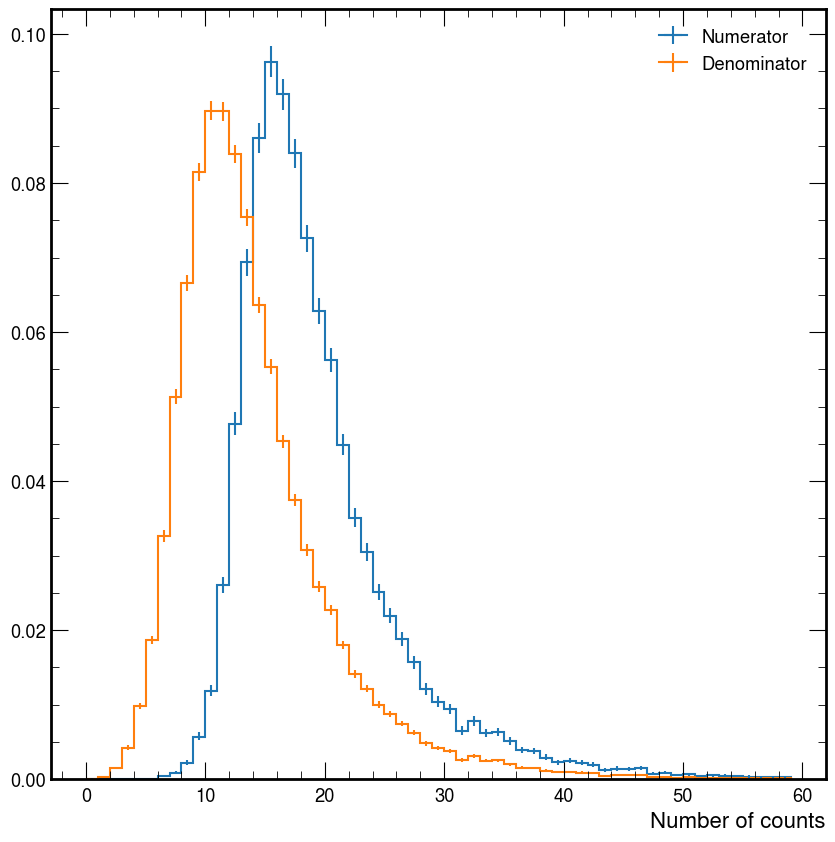

In [35]:
numerator, bins_num = np.histogram(num, bins)
print (numerator)
denominator, bins_den  = np.histogram(den, bins)
print (denominator)

fig, ax = plt.subplots()
mplhep.histplot(numerator, yerr = True, density = True, label = "Numerator")
mplhep.histplot(denominator, yerr = True, density = True, label = "Denominator")
ax.set_xlabel("Number of counts")
ax.legend()
plt.savefig("Number of counts.png")

In [36]:
index_removal = []
print ("Denominator:", denominator)
print ("Numerator:", numerator)
for (index, value) in enumerate(denominator):
    if (value == 0):
        index_removal.append(index)

print (index_removal)
den = np.delete(denominator, index_removal)
print ("den:", den)
num  = np.delete(numerator, index_removal)
print ("num:", num)
print (len(numerator))
print (len(denominator))
print (bins_num)
bins_num_removed = np.delete(bins_num, index_removal)
print (bins_num_removed)

Denominator: [   0   13   81  236  547 1040 1816 2861 3710 4539 4997 4994 4673 4200
 3544 3085 2525 2087 1713 1440 1265 1003  786  676  557  485  415  347
  267  232  209  143  172  136  140  112   86   83   64   50   54   49
   42   27   31   30   32   16   19   12   14    9   11   10    9    7
    6    6    6]
Numerator: [   0    0    0    0    0    0    9   19   49  126  262  575 1054 1532
 1900 2127 2030 1855 1603 1388 1243  991  775  673  555  484  414  346
  267  230  208  143  172  136  140  112   86   83   64   50   54   49
   42   27   31   30   32   16   19   12   14    9   11   10    9    7
    6    6    6]
[0]
den: [  13   81  236  547 1040 1816 2861 3710 4539 4997 4994 4673 4200 3544
 3085 2525 2087 1713 1440 1265 1003  786  676  557  485  415  347  267
  232  209  143  172  136  140  112   86   83   64   50   54   49   42
   27   31   30   32   16   19   12   14    9   11   10    9    7    6
    6    6]
num: [   0    0    0    0    0    9   19   49  126  262  575 1054 153

In [39]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency, unc_eff = eff_determine_unc(num, den)
print (efficiency)
yerr = [unc_eff[0], unc_eff[1]]
print (yerr)

[0.         0.         0.         0.         0.         0.00495595
 0.00664103 0.01320755 0.02775942 0.05243146 0.11513817 0.22555104
 0.3647619  0.53611738 0.68946515 0.8039604  0.88883565 0.93578517
 0.96388889 0.9826087  0.98803589 0.98600509 0.99556213 0.99640934
 0.99793814 0.99759036 0.99711816 1.         0.99137931 0.99521531
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]
[array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00161906, 0.00150705, 0.00187117, 0.00244104, 0.00316133,
       0.00453804, 0.00616069, 0.00751307, 0.0085272 , 0.00855416,
       0.00822093, 0.00731294, 0.00648327, 0.00561351, 0.00450435,
       0.00450861, 0.00556382, 0.00429796, 0.00471614, 0.00472518,
       0.00551903, 0.00659542, 0.00687149, 0.01

[ 15.25423729  25.42372881  35.59322034  45.76271186  55.93220339
  66.10169492  76.27118644  86.44067797  96.61016949 106.77966102
 116.94915254 127.11864407 137.28813559 147.45762712 157.62711864
 167.79661017 177.96610169 188.13559322 198.30508475 208.47457627
 218.6440678  228.81355932 238.98305085 249.15254237 259.3220339
 269.49152542 279.66101695 289.83050847 300.         310.16949153
 320.33898305 330.50847458 340.6779661  350.84745763 361.01694915
 371.18644068 381.3559322  391.52542373 401.69491525 411.86440678
 422.03389831 432.20338983 442.37288136 452.54237288 462.71186441
 472.88135593 483.05084746 493.22033898 503.38983051 513.55932203
 523.72881356 533.89830508 544.06779661 554.23728814 564.40677966
 574.57627119 584.74576271 594.91525424]
[array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00161906, 0.00150705, 0.00187117, 0.00244104, 0.00316133,
       0.00453804, 0.00616069, 0.00751307, 0.0085272 , 0.00855416,
       0.00822093, 0.00731294, 0

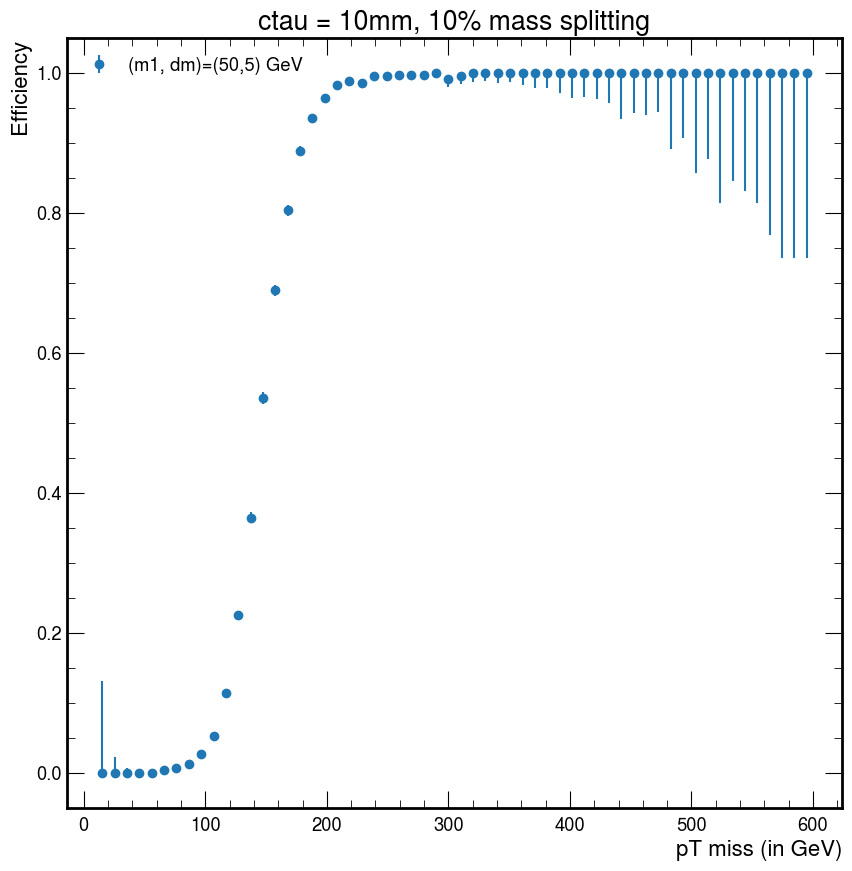

In [40]:
bins_x = (bins_num_removed[:-1] + bins_num_removed[1:])*(0.5)
print(bins_x)
plt.errorbar(bins_x, efficiency, yerr , fmt='o', label = '(m1, dm)=(50,5) GeV')
plt.xlabel("pT miss (in GeV)")
plt.ylabel("Efficiency")
plt.title ("ctau = 10mm, 10% mass splitting")
plt.legend()
plt.savefig("Eff_latest.png")
print (yerr)